In [ ]:
# 1. 匯入相關套件
from IPython.display import clear_output
import os
import pandas as pd
from transformers import (
    BertTokenizerFast,
    AutoModelForCausalLM,  # 使用 CausalLM 進行 generation 任務
    Trainer,
    TrainingArguments
)
import matplotlib.pyplot as plt
import pprint
clear_output()

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-chinese')
model = AutoModelForCausalLM.from_pretrained('ckiplab/gpt2-base-chinese')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/421M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/421M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: ckiplab/gpt2-base-chinese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 查詢 special tokens

print("Special tokens map:", tokenizer.special_tokens_map)
print("All special tokens:", tokenizer.all_special_tokens)

Special tokens map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
All special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [ ]:
# 查詢最大支援長度

print("Maximum sequence length:", tokenizer.model_max_length)

Maximum sequence length: 512


In [ ]:
!wget 'https://github.com/HsiaoEn/nlp-transformer/releases/download/news_topic_summary/train.jsonl'
!wget 'https://github.com/HsiaoEn/nlp-transformer/releases/download/news_topic_summary/public.jsonl'

--2026-03-12 08:38:38--  https://github.com/HsiaoEn/nlp-transformer/releases/download/news_topic_summary/train.jsonl
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/464369906/b11f805d-d87a-4c04-9632-77daa50a3a64?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-12T09%3A26%3A15Z&rscd=attachment%3B+filename%3Dtrain.jsonl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-12T08%3A25%3A44Z&ske=2026-03-12T09%3A26%3A15Z&sks=b&skv=2018-11-09&sig=JJqDTYK4axC7XxeSBjxKDoMmCz3Vx%2FA5S01ERYJa7QU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzMwODMxOCwibmJmIjoxNzczMzA0NzE4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVj

## EDA (Exploratory Data Analysis)

In [ ]:
# 讀取 JSONL 檔案 (假設檔案位於當前目錄)
train_df = pd.read_json("train.jsonl", lines=True)
val_df = pd.read_json("public.jsonl", lines=True)

In [ ]:
train_df.head()

,date_publish,title,source_domain,maintext,split,id
0,2015-03-02 00:00:00,榜首進台大醫科卻休學 、27歲拿到法國天文博士 李悅寧跌破眾人眼鏡返台任教,udn.com,從小就很會念書的李悅寧， 在眾人殷殷期盼下，以榜首之姿進入臺大醫學院， 但始終忘不了對天文的...,train,0
1,2015-10-20 00:00:00,「猩人」真有其事？人猿混種曾成功受孕 揭秘前蘇聯可怕實驗,udn.com,人類與猩猩混種誕下後代，不一定僅限於科幻電影情節。前蘇聯科學家早在1920年代以人工授精技術...,train,1
2,2015-12-10 00:00:00,跑步小品／謝謝三浦春馬 再次喚醒我對跑步的熱情,udn.com,從得知三浦春馬離世的消息那刻開始，心中頓時感到很鬱悶，那種很驚訝、很可惜、很無奈的感覺很重很...,train,2
3,2016-04-22 00:00:00,【身體不適特輯（下）】「拉肚子」、「想吐」、「嘔吐」英文怎麼說？,udn.com,嗨，歡迎回到【身體不適特輯】的下集，在這集裡，小編會繼續講自己食物中毒的故事，以及介紹各種症...,train,3
4,2016-04-29 00:00:00,中職／球彈、好球帶小 投手被打趴百害無一利,udn.com,今年中華職棒官辦熱身賽眾家打者真的打瘋了！數據顯示，官辦熱身賽打了20場，竟然出現多達66轟...,train,4


In [ ]:
val_df.head()

,date_publish,title,source_domain,maintext,split,id
0,2021-01-14 00:00:00,Anker新款真無線藍牙耳機Liberty Air 2 Pro 引進台灣市場,udn.com,Anker在此次CES 2021中，宣布以旗下Soundcore品牌推出新款真無線藍牙耳機L...,dev,21710
1,2021-01-14 00:00:00,藍染、客家美食、舊山線自行車 「苗栗一日遊」超人氣美食美景,udn.com,來到了苗栗旅遊，除了有超人氣的舊山線鐵道自行車外，還有絕不能錯過的客家美食，讓我們跟著兩個女...,dev,21711
2,2021-01-14 00:00:00,華碩打造對應軍規防護與2 in 1設計的15.6吋Chromebook,udn.com,如同其他品牌選擇在CES 2021公布新款Chromebook產品，華碩也宣布推出換上Int...,dev,21712
3,2021-01-14 00:00:00,產業發展變革 台灣的優勢與機會,udn.com,文．洪寶山\n疫情改變全球的生活型態，也改變產業的發展，有些產業受到嚴重波及、有些產業繼之興...,dev,21713
4,2021-01-14 00:00:00,全球Windows 7裝置粗估至少還有1億台以上 市佔率穩穩卡在20％,udn.com,在 2020 年 1 月 14 日，Windows 7 已經正式退出消費市場，不再得到微軟任...,dev,21714


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21710 entries, 0 to 21709
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date_publish   21710 non-null  object
 1   title          21710 non-null  object
 2   source_domain  21710 non-null  object
 3   maintext       21710 non-null  object
 4   split          21710 non-null  object
 5   id             21710 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1017.8+ KB


In [ ]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date_publish   5494 non-null   object
 1   title          5494 non-null   object
 2   source_domain  5494 non-null   object
 3   maintext       5494 non-null   object
 4   split          5494 non-null   object
 5   id             5494 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 257.7+ KB


語言模型輸入長度有其限制，首先需要查看 input text 與 target text 的長度

Token indices sequence length is longer than the specified maximum sequence length for this model (3297 > 512). Running this sequence through the model will result in indexing errors


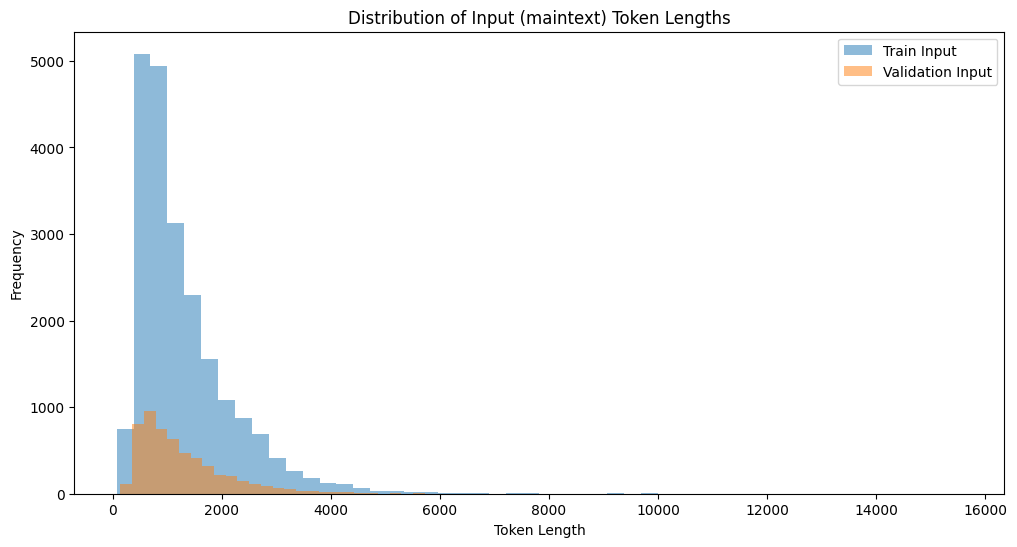

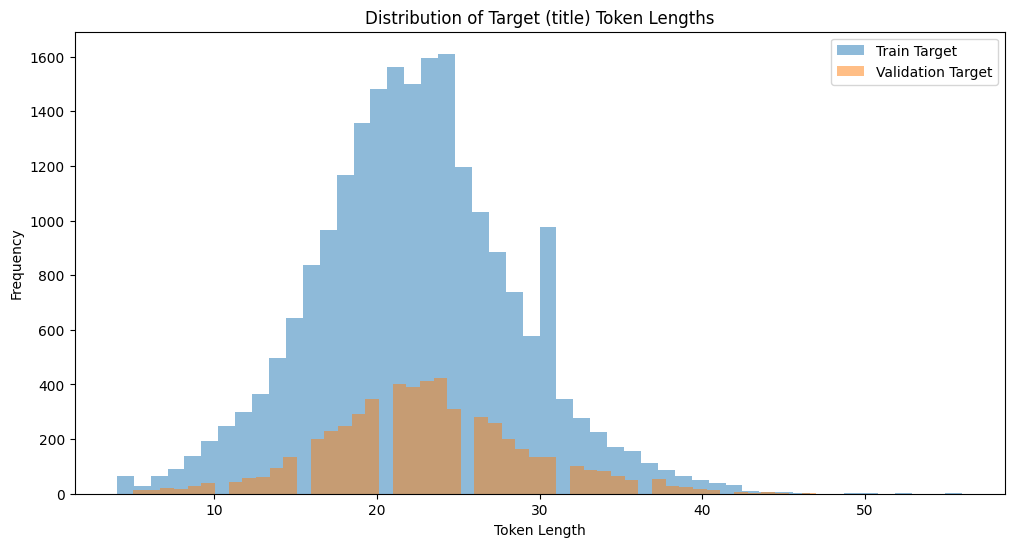

In [ ]:
# 計算 token 長度的函式
def compute_token_lengths(text_series, prefix=""):
    lengths = []
    for text in text_series:
        # 將 prefix 加入（例如 "summarize: "）以模擬訓練時的輸入格式
        full_text = prefix + text
        # 使用 tokenizer.tokenize() 可以取得 token 列表
        tokens = tokenizer.tokenize(full_text)
        lengths.append(len(tokens))
    return lengths

# 設定 prefix (僅用於 input 文章)
input_prefix = "summarize: "

# 計算訓練資料與驗證資料中：
# 1. 輸入文章 (maintext) 的 token 長度分布
# 2. 摘要 (title) 的 token 長度分布
train_input_lengths = compute_token_lengths(train_df["maintext"], prefix=input_prefix)
train_target_lengths = compute_token_lengths(train_df["title"])
val_input_lengths = compute_token_lengths(val_df["maintext"], prefix=input_prefix)
val_target_lengths = compute_token_lengths(val_df["title"])

# 畫出輸入文章的 token 長度分布
plt.figure(figsize=(12, 6))
plt.hist(train_input_lengths, bins=50, alpha=0.5, label="Train Input")
plt.hist(val_input_lengths, bins=50, alpha=0.5, label="Validation Input")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Distribution of Input (maintext) Token Lengths")
plt.legend()
plt.show()

# 畫出摘要的 token 長度分布
plt.figure(figsize=(12, 6))
plt.hist(train_target_lengths, bins=50, alpha=0.5, label="Train Target")
plt.hist(val_target_lengths, bins=50, alpha=0.5, label="Validation Target")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Distribution of Target (title) Token Lengths")
plt.legend()
plt.show()

In [ ]:
print(f'Maximum of train target length: {max(train_target_lengths)}')
print(f'Maximum of val target length: {max(val_target_lengths)}')

Maximum of train target length: 56
Maximum of val target length: 47


## Data Preprocessing



**`add_special_tokens`**： *Add a dictionary of special tokens (eos, pad, cls, etc.) to the encoder and link them to class attributes. If special tokens are NOT in the vocabulary, they are added to it (indexed starting from the last index of the current vocabulary).*

[Hugging Face Transformer Tokenizer](https://huggingface.co/docs/transformers/main_classes/tokenizer)

**`resize_token_embeddings`**： Resizes input token embeddings matrix of the model if new_num_tokens != config.vocab_size.

[Hugging Face Transformer Models](https://huggingface.co/docs/transformers/main_classes/model)

In [ ]:
# 新增 [EOS] token (若尚未存在)
if "[EOS]" not in tokenizer.get_vocab():
    tokenizer.add_special_tokens({'eos_token': '[EOS]'})
    # 若後續 fine-tune 模型，記得調整模型的 embedding 層:
    # model.resize_token_embeddings(len(tokenizer))
    model.resize_token_embeddings(len(tokenizer))


# 印出特殊 token 確認
print("SEP token:", tokenizer.sep_token)       # 如 "[SEP]"
print("PAD token:", tokenizer.pad_token)       # 如 "[PAD]"
print("EOS token:", tokenizer.eos_token)       # 新增的 "[EOS]"
print(f"EOS Token ID: {tokenizer.eos_token_id}")

SEP token: [SEP]
PAD token: [PAD]
EOS token: [EOS]
EOS Token ID: 21128


In [ ]:
print(tokenizer.special_tokens_map)

{'eos_token': '[EOS]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


定義輸入格式為: \
**`「summarize: [文章內容] [SEP] [摘要標題] [EOS]」`**

利用 `[SEP]` 來區分 `文章內容` 與 `摘要標題`

[CrossEntropyLoss](https://docs.pytorch.org/docs/main/generated/torch.nn.CrossEntropyLoss.html)

In [ ]:
special_text = "summarize: " + "[SEP]" + "[EOS]"
ids = tokenizer.encode(special_text, add_special_tokens=False)
print(f'Text: "{special_text}"')
print(f'Tokens: {tokenizer.convert_ids_to_tokens(ids)}')
print(f'Token count: {len(ids)}')

Text: "summarize: [SEP][EOS]"
Tokens: ['su', '##mma', '##ri', '##ze', ':', '[SEP]', '[EOS]']
Token count: 7


In [ ]:
def process_example(input_text, target_text, tokenizer, max_length=512, max_input_length=449):
    """
    處理單筆資料，組合成序列：
      "summarize: " + input_text + "[SEP]" + target_text + "[EOS]"
    並且建立 labels：
      - 對 "summarize: "、input_text 以及 [SEP] 部分，labels 設為 -100
      - 對 target_text 及 [EOS] 則保留原 token id (用於計算 loss)

    若 input_text token 長度超過 max_input_length (449) 則截斷，
    最後組合後若不足 max_length (512) 則 padding 到 512。
    """
    prefix = "summarize: "

    # 分別 tokenize (不自動加入 special tokens)
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    input_ids = tokenizer.encode(input_text, add_special_tokens=False)
    target_ids = tokenizer.encode(target_text, add_special_tokens=False)

    # 取得特殊 token 的 id
    sep_id = tokenizer.sep_token_id  # [SEP]
    eos_id = tokenizer.eos_token_id  # [EOS]

    # 截斷 input text token 長度到 max_input_length (449)
    if len(input_ids) > max_input_length:
        input_ids = input_ids[:max_input_length]

    # 組合最終序列：prefix + truncated input_ids + [SEP] + target_ids + [EOS]
    final_ids = prefix_ids + input_ids + [sep_id] + target_ids + [eos_id]

    # 建立 labels，初始先複製 final_ids
    labels = final_ids.copy()
    # 將 prefix, input text 以及 [SEP] token 部分設為 -100 (不參與 loss 計算)
    mask_until = len(prefix_ids) + len(input_ids) + 1  # +1 表示 [SEP] 的位置
    for i in range(mask_until):
        labels[i] = -100

    # Padding：若總長度不足 max_length (512) 則 padding，且 padding token 的 label 也設為 -100
    if len(final_ids) < max_length:
        pad_length = max_length - len(final_ids)
        final_ids = final_ids + [tokenizer.pad_token_id] * pad_length
        labels = labels + [-100] * pad_length
    # else:
    #     # 若超過 max_length（理論上經過截斷後不會超過），則直接截斷
    #     final_ids = final_ids[:max_length]
    #     labels = labels[:max_length]

    # 建立 attention mask：非 padding token 為 1，padding token 為 0
    attention_mask = [1 if token_id != tokenizer.pad_token_id else 0 for token_id in final_ids]

    return {
        "input_ids": final_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

# 示範處理第一筆資料
example_train = train_df.iloc[0]
input_text = example_train["maintext"]
target_text = example_train["title"]

processed = process_example(input_text, target_text, tokenizer)
print("Processed sequence length:", len(processed["input_ids"]))  # 應為 512
print("Attention mask:", processed["attention_mask"])
print("Labels sample:", processed["labels"])

Processed sequence length: 512
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
# 將處理應用於整份資料（可利用 DataFrame.apply）
def process_row(row):
    return process_example(row["maintext"], row["title"], tokenizer)

train_df["processed"] = train_df.apply(process_row, axis=1)
val_df["processed"] = val_df.apply(process_row, axis=1)

train_df.head()

,date_publish,title,source_domain,maintext,split,id,processed
0,2015-03-02 00:00:00,榜首進台大醫科卻休學 、27歲拿到法國天文博士 李悅寧跌破眾人眼鏡返台任教,udn.com,從小就很會念書的李悅寧， 在眾人殷殷期盼下，以榜首之姿進入臺大醫學院， 但始終忘不了對天文的...,train,0,"{'input_ids': [11541, 13292, 8641, 9349, 131, ..."
1,2015-10-20 00:00:00,「猩人」真有其事？人猿混種曾成功受孕 揭秘前蘇聯可怕實驗,udn.com,人類與猩猩混種誕下後代，不一定僅限於科幻電影情節。前蘇聯科學家早在1920年代以人工授精技術...,train,1,"{'input_ids': [11541, 13292, 8641, 9349, 131, ..."
2,2015-12-10 00:00:00,跑步小品／謝謝三浦春馬 再次喚醒我對跑步的熱情,udn.com,從得知三浦春馬離世的消息那刻開始，心中頓時感到很鬱悶，那種很驚訝、很可惜、很無奈的感覺很重很...,train,2,"{'input_ids': [11541, 13292, 8641, 9349, 131, ..."
3,2016-04-22 00:00:00,【身體不適特輯（下）】「拉肚子」、「想吐」、「嘔吐」英文怎麼說？,udn.com,嗨，歡迎回到【身體不適特輯】的下集，在這集裡，小編會繼續講自己食物中毒的故事，以及介紹各種症...,train,3,"{'input_ids': [11541, 13292, 8641, 9349, 131, ..."
4,2016-04-29 00:00:00,中職／球彈、好球帶小 投手被打趴百害無一利,udn.com,今年中華職棒官辦熱身賽眾家打者真的打瘋了！數據顯示，官辦熱身賽打了20場，竟然出現多達66轟...,train,4,"{'input_ids': [11541, 13292, 8641, 9349, 131, ..."


In [ ]:
# 確認所有資料的序列長度皆為 512
train_lengths = train_df["processed"].apply(lambda x: len(x["input_ids"]))
val_lengths = val_df["processed"].apply(lambda x: len(x["input_ids"]))

print("Train sequence lengths (unique):", train_lengths.unique())
print("Validation sequence lengths (unique):", val_lengths.unique())

Train sequence lengths (unique): [512]
Validation sequence lengths (unique): [512]


In [ ]:
print(train_df['processed'][0].keys())

dict_keys(['input_ids', 'attention_mask', 'labels'])


## Dataset & Dataloader

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, get_linear_schedule_with_warmup
from torch.optim import AdamW # Import AdamW from torch.optim
from tqdm.auto import tqdm

# 自訂 PyTorch Dataset，假設 dataframe 的 "processed" 欄位存放每筆資料處理後的 dict
class SummarizationDataset(Dataset):
    def __init__(self, dataframe):
        # 將每筆資料以 dict 格式存成 list
        self.examples = dataframe["processed"].tolist()

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        # 將 list 中每筆資料轉成 tensor，注意各個 key 皆需轉成 tensor
        item = self.examples[idx]
        return {key: torch.tensor(val, dtype=torch.long) for key, val in item.items()}

# 假設你已經讀取並處理資料存於 train_df 與 val_df
# 以下建立訓練與驗證的 Dataset 物件：
train_dataset = SummarizationDataset(train_df)
val_dataset = SummarizationDataset(val_df)

# 接著建立 DataLoader，設定 batch_size 與 shuffle 參數
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# 示範取出一個 batch 的資料
for batch in train_dataloader:
    print("Batch input_ids shape:", batch["input_ids"].shape)
    print("Batch attention_mask shape:", batch["attention_mask"].shape)
    print("Batch labels shape:", batch["labels"].shape)
    break

Batch input_ids shape: torch.Size([8, 512])
Batch attention_mask shape: torch.Size([8, 512])
Batch labels shape: torch.Size([8, 512])


In [ ]:
pprint.pp(train_dataset[0])

{'input_ids': tensor([11541, 13292,  8641,  9349,   131,  2537,  2207,  2218,  2523,  3298,
         2573,  3292,  4638,  3330,  2633,  2180,  8024,  1762,  4707,   782,
         3668,  3668,  3309,  4687,   678,  8024,   809,  3528,  7674,   722,
         2013,  6868,  1057,  5637,  1920,  7015,  2119,  7368,  8024,   852,
         1993,  5173,  2563,   679,   749,  2205,  1921,  3152,  4638,  4229,
         2658,   511,  1920,  2119,  1724,  2399,  5159,   671,  1842,  6895,
         6121,  2527,  8024,  1961,  3748,  2552,  6895,  6626,  3791,  1751,
         3122,  6364,  1921,  3152,  1300,  1894,   511,  2537,  2207,  3760,
         2682,  6882,  4534,  5439,  2374,  4638,  1961,  8024,  1086,  2428,
         6649,  4788,  4707,   782,  4706,  7128,  6819,  1378,   818,  3136,
         8024,  1372,  4158,  2396,  1221,  2205,  1921,  3152,  3300,  5646,
         6637,  4638,  2119,  4495,  8024,  2208,  6624,  7953,  1096,  3356,
         6662,   511,   753,   472,   671,   736, 

## Training

利用 Hugging Face 的 Trainer 避開自己寫繁瑣的訓練流程

[Trainer](https://huggingface.co/docs/transformers/v5.3.0/en/main_classes/trainer#transformers.Trainer)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.449072
200,3.997200
300,3.816903
400,3.755918
500,3.613146
600,3.485916
700,3.370804
800,3.199334
900,3.099114
1000,3.133358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to 'fine_tuned_model'


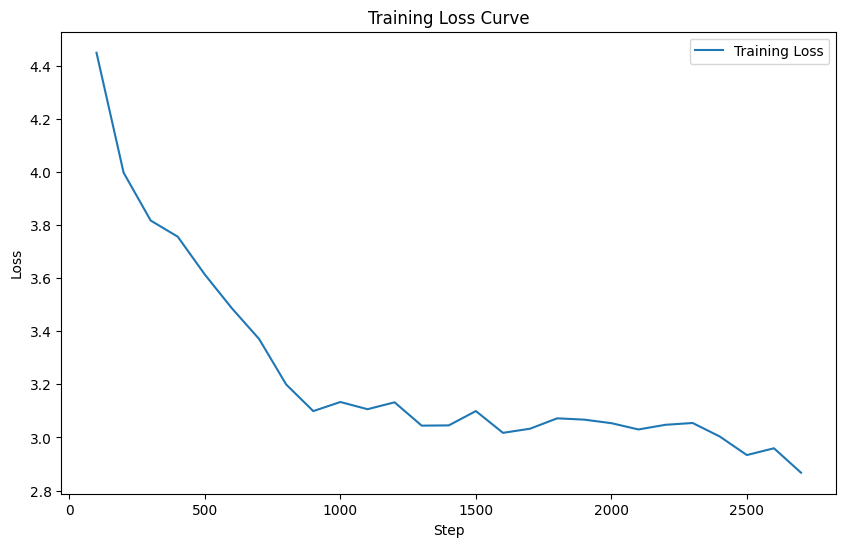

In [ ]:
# 定義 compute_metrics (用 loss 作為唯一 metric，實際上 Trainer 內建 logging loss)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 這裡可以計算其他評估指標，本例僅回傳空 dict
    return {}

# 訓練超參數設定
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    warmup_steps=int(0.1 * len(train_dataset)),  # 或者依據 total_steps 設定
    weight_decay=0.01,
    logging_steps=100,
    # evaluation_strategy="no",  # 若沒有 eval_dataset, 可以關閉驗證步驟
    # save_strategy="no",        # 此例僅示範訓練 loop，不自動儲存 checkpoint
    disable_tqdm=False,          # 確保啟用進度條
    report_to="none"
)

# 建立 Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    # 如果有 eval_dataset 可加入 eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

# 訓練前先記錄初始 loss history (Trainer 並不會自動回傳每個 batch loss，
# 若需要記錄 loss 曲線，可使用 callback 或自訂 logging function，
# 這裡以簡單方式示範如何取出訓練後的 logs)
train_result = trainer.train()

# 儲存訓練後的模型與 tokenizer
trainer.save_model("fine_tuned_model")
tokenizer.save_pretrained("fine_tuned_model")
print("Fine-tuned model saved to 'fine_tuned_model'")

# 如果需要顯示 loss 曲線，可從 trainer.state.log_history 中提取 loss 值
loss_history = [entry["loss"] for entry in trainer.state.log_history if "loss" in entry]
steps = [entry["step"] for entry in trainer.state.log_history if "loss" in entry]

plt.figure(figsize=(10, 6))
plt.plot(steps, loss_history, label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

## Inference
分別以下面以種 Strategies 進行文字生成:


*   Greedy
*   Beam Search
*   Sampling
*   Tok-k Sampling
*   Top-p Sampling
*   Temperature Scaling



[Generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

In [ ]:
import random

val_texts = []
for sample in val_dataset:
    # 解碼時保留 special tokens（後續自行切分）
    text = tokenizer.decode(sample["input_ids"], skip_special_tokens=False, clean_up_tokenization_spaces=False)
    val_texts.append(text)

# 隨機選出三篇文章
selected_texts = random.sample(val_texts, 3)
pprint.pp(selected_texts)

['summarize : 【 文 ‧ 臺 中 市 政 府 文 化 局 】 由 臺 中 市 政 府 文 化 局 主 辦 的 「 第 九 屆 臺 中 文 學 '
 '獎 」 創 下 多 項 新 紀 錄 ！ 2020 年 總 計 收 到 海 內 外 共 1, 909 件 投 稿 作 品 ， 成 長 幅 度 達 73 % '
 '， 文 化 局 也 提 高 總 獎 金 額 度 達 180 萬 元 ， 選 出 1 位 文 學 貢 獻 獎 得 主 瓦 歷 斯 ． 諾 幹 ， 以 及 '
 '73 件 文 學 創 作 獎 作 品 ， 顯 示 臺 中 市 政 府 在 文 學 推 廣 上 的 豐 碩 成 果 。 收 件 創 新 高 扎 根 文 學 '
 '推 廣 3 月 13 日 在 臺 中 文 學 館 舉 辦 頒 獎 典 禮 ， 市 長 盧 秀 燕 親 自 出 席 並 表 示 ， 臺 中 文 學 獎 是 '
 '臺 中 市 政 府 非 常 重 要 的 獎 項 ， 第 九 屆 的 參 選 作 品 數 量 創 新 高 ， 也 增 加 古 典 詩 的 類 別 ， 感 '
 '謝 評 審 老 師 的 辛 勞 付 出 ， 加 深 文 學 的 推 廣 和 扎 根 。 市 長 也 感 謝 瓦 歷 斯 ． 諾 幹 老 師 在 文 學 '
 '創 作 及 原 住 民 文 化 教 育 所 做 的 貢 獻 ， 並 頒 發 文 學 貢 獻 獎 。 瓦 歷 斯 ． 諾 幹 表 示 ， 臺 中 市 擁 '
 '有 偉 大 的 文 學 傳 統 和 文 學 精 神 。 小 說 類 第 一 名 由 林 楷 倫 〈 北 疆 沒 有 大 紅 色 的 魚 〉 獲 得 ， '
 '以 賣 魚 為 職 業 的 作 者 ， 寫 出 打 漁 人 的 生 命 困 境 與 孤 寂 。 散 文 類 第 一 名 為 董 秉 哲 〈 口 〉 ， '
 '細 膩 書 寫 兒 子 與 生 病 的 父 親 間 那 份 不 輕 易 顯 露 卻 真 摯 的 情 感 。 新 詩 類 第 一 名 為 來 自 馬 來 '
 '西 亞 的 李 寧 介 〈 無 事 〉 ， 不 直 寫 疫 情 ， 而 以 襯 托 對 照 的 方 式 ， 讓 自 然 環 境 與 人 類 的 疫 情 '
 '建 [SEP] 第 九 屆 臺 中 文 學 獎 頒 獎 典 禮 文 學

In [ ]:
# 取得特殊 token 的字串
sep_token = tokenizer.sep_token  # 例如 "[SEP]"
eos_token = tokenizer.eos_token

for full_text in selected_texts:
    # 切分原始文本 (格式："summarize: " + input text + [SEP] + target text + [EOS])

    parts = full_text.split(sep_token, 1)
    # prompt_part 為 "summarize: " + input text + [SEP]
    prompt_part = parts[0].strip() + sep_token
    # ground_truth 為 [SEP] 之後的部分 (包含 target text 與 [EOS])
    ground_truth = parts[1].strip()

    # 將 prompt_truncated 轉換成 tensor (作為模型輸入)
    input_ids = tokenizer.encode(prompt_part, return_tensors="pt").to(model.device)
    attention_mask = torch.ones_like(input_ids)

    # 取得原始 prompt 的 token 長度 (這部分不希望出現在最終輸出中)
    prompt_length = input_ids.shape[1]

    # 使用不同 decoding strategies 進行生成，設定 max_new_tokens=64
    # 1. Greedy decoding
    greedy_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=False
    )
    # 取生成結果中除去 prompt 部分的 tokens
    greedy_pred = tokenizer.decode(greedy_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 2. Beam Search (num_beams=5)
    beam_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        num_beams=5,
        early_stopping=True
    )
    beam_pred = tokenizer.decode(beam_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 3. Top-k Sampling (top_k=50)
    topk_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        top_k=50
    )
    topk_pred = tokenizer.decode(topk_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 4. Top-p Sampling (top_p=0.9)
    topp_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        top_p=0.9
    )
    topp_pred = tokenizer.decode(topp_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 5. Temperature Scaling (temperature=1.5)
    temp_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        temperature=1.5
    )
    temp_pred = tokenizer.decode(temp_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 將 ground_truth 解碼時也去除 special tokens
    ground_truth_clean = tokenizer.decode(tokenizer.encode(ground_truth, add_special_tokens=False),
                                          skip_special_tokens=True,
                                          clean_up_tokenization_spaces=True)

    # 顯示結果：只呈現在 [SEP] 後面生成的文字 (也就是 summarization 部分)
    print("====================================")
    print("原始輸入文本 (Prompt):")
    pprint.pp(prompt_part)
    print("\nGround Truth Title:")
    pprint.pp(ground_truth_clean)
    print("\n【Greedy Decoding】")
    pprint.pp(greedy_pred)
    print("\n【Beam Search】")
    pprint.pp(beam_pred)
    print("\n【Top-k Sampling】")
    pprint.pp(topk_pred)
    print("\n【Top-p Sampling】")
    pprint.pp(topp_pred)
    print("\n【Temperature Scaling】")
    pprint.pp(temp_pred)
    print("====================================\n")

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 【 文 ‧ 臺 中 市 政 府 文 化 局 】 由 臺 中 市 政 府 文 化 局 主 辦 的 「 第 九 屆 臺 中 文 學 '
 '獎 」 創 下 多 項 新 紀 錄 ！ 2020 年 總 計 收 到 海 內 外 共 1, 909 件 投 稿 作 品 ， 成 長 幅 度 達 73 % '
 '， 文 化 局 也 提 高 總 獎 金 額 度 達 180 萬 元 ， 選 出 1 位 文 學 貢 獻 獎 得 主 瓦 歷 斯 ． 諾 幹 ， 以 及 '
 '73 件 文 學 創 作 獎 作 品 ， 顯 示 臺 中 市 政 府 在 文 學 推 廣 上 的 豐 碩 成 果 。 收 件 創 新 高 扎 根 文 學 '
 '推 廣 3 月 13 日 在 臺 中 文 學 館 舉 辦 頒 獎 典 禮 ， 市 長 盧 秀 燕 親 自 出 席 並 表 示 ， 臺 中 文 學 獎 是 '
 '臺 中 市 政 府 非 常 重 要 的 獎 項 ， 第 九 屆 的 參 選 作 品 數 量 創 新 高 ， 也 增 加 古 典 詩 的 類 別 ， 感 '
 '謝 評 審 老 師 的 辛 勞 付 出 ， 加 深 文 學 的 推 廣 和 扎 根 。 市 長 也 感 謝 瓦 歷 斯 ． 諾 幹 老 師 在 文 學 '
 '創 作 及 原 住 民 文 化 教 育 所 做 的 貢 獻 ， 並 頒 發 文 學 貢 獻 獎 。 瓦 歷 斯 ． 諾 幹 表 示 ， 臺 中 市 擁 '
 '有 偉 大 的 文 學 傳 統 和 文 學 精 神 。 小 說 類 第 一 名 由 林 楷 倫 〈 北 疆 沒 有 大 紅 色 的 魚 〉 獲 得 ， '
 '以 賣 魚 為 職 業 的 作 者 ， 寫 出 打 漁 人 的 生 命 困 境 與 孤 寂 。 散 文 類 第 一 名 為 董 秉 哲 〈 口 〉 ， '
 '細 膩 書 寫 兒 子 與 生 病 的 父 親 間 那 份 不 輕 易 顯 露 卻 真 摯 的 情 感 。 新 詩 類 第 一 名 為 來 自 馬 來 '
 '西 亞 的 李 寧 介 〈 無 事 〉 ， 不 直 寫 疫 情 ， 而 以 襯 托 對 照 的 方 式 ， 讓 自 然 環 境 與 人 類 的 疫 情 '
 '建[SEP]')

Ground T

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 今 ( 27 ) 日 火 箭 主 場 迎 戰 巫 師 ， 兩 隊 整 場 打 得 難 分 難 捨 ， 而 兩 位 互 換 東 家 '
 '的 巨 星 沃 爾 ( [UNK] [UNK] ) 與 衛 斯 特 布 魯 克 ( [UNK] [UNK] ) 在 末 節 更 是 上 演 口 水 戰 '
 '， 最 終 雙 雙 各 吞 技 術 犯 規 收 場 。 [UNK] [UNK] for [UNK] [UNK] and [UNK] [UNK] '
 '[UNK] ( via @ [UNK] ) pic. twitter. com / [UNK] [UNK] [UNK] ( @ [UNK] ) '
 '[UNK] 27, 2021 比 賽 剩 下 5 分 多 鐘 時 ， 衛 斯 特 布 魯 克 在 一 次 切 入 上 籃 造 成 沃 爾 犯 規 ， 隨 '
 '後 衛 斯 特 布 魯 克 口 中 念 念 有 詞 ， 沃 爾 也 不 甘 示 弱 上 前 交 換 語 言 ， 而 裁 判 也 立 即 將 兩 人 隔 '
 '開 ， 並 各 給 雙 方 一 次 技 術 犯 規 ， 沃 爾 更 是 在 衛 斯 特 布 魯 克 罰 球 時 鼓 掌 ， 挑 釁 意 味 十 足 。 '
 '不 過 賽 後 沃 爾 則 顯 得 雲 淡 風 輕 ， 表 示 這 只 是 籃 球 場 上 常 有 的 垃 圾 話 ， 「 這 是 兩 個 具 有 競 '
 '爭 力 的 選 手 展 現 自 我 的 時 刻 ， 這 幾 年 來 衛 斯 特 布 魯 克 一 直 壓 著 我 打 ， 自 從 我 進 入 聯 盟 後 '
 '， 這 只 是 我 對 衛 斯 特 布 魯 克 的 第 三 場 勝 利 ， 也 代 表 著 他 是 不 服 輸 的 悍 將 。 」 沃 爾 也 稱 讚 '
 '衛 斯 特 布 魯 克 一 番 ， 「 我 知 道 他 和 我 一 樣 受 到 了 傷 害 ， 我 們 也 嘗 試 著 努 力 變 得 更 好 ， 試 '
 '圖 帶 領 我 們 的 球 隊 向 前 邁 進 ， 這 不 是 我 們 第 一 次 以 垃 圾 話 惹 怒 對 方 ， 我 知 道 他 有 多 棒 。 '
 '」 而 衛 斯 特 布 魯 克 則 顯 得 怒 火 中

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 從 路 邊 攤 賣 到 開 店 面 的 鍋 貼 店 ， 一 賣 就 是 20 多 年 ， 當 天 新 鮮 備 料 不 賣 隔 夜 '
 '貨 ， 在 地 人 從 小 吃 到 大 ， 還 有 老 饕 必 點 的 古 早 味 煎 餅 ， 每 日 限 量 晚 來 吃 不 到 ， 經 常 一 開 '
 '店 就 人 潮 滿 滿 ， 老 闆 忙 到 手 都 沒 停 過 。 店 面 外 觀 ： 這 個 是 府 前 店 ， 總 店 在 永 福 路 二 段 。 '
 '府 前 店 有 賣 下 午 時 段 ， 居 然 下 午 3 點 一 開 店 就 一 堆 人 ， 連 內 用 桌 都 坐 滿 了 ， 在 旁 邊 看 老 '
 '闆 忙 到 手 都 沒 停 過 。 產 品 都 是 當 天 新 鮮 備 料 ， 現 場 手 工 包 製 ， 不 賣 隔 夜 貨 ， 每 天 只 準 備 '
 '固 定 量 ， 賣 完 就 沒 了 。 菜 單 （ 2021 年 1 月 ） 老 饕 們 最 愛 的 就 是 這 個 古 早 蔬 菜 煎 餅 ， 都 是 '
 '現 點 現 煎 ， 每 鍋 每 次 只 能 煎 8 片 ， 人 多 時 要 稍 微 等 一 下 。 早 蔬 菜 煎 餅 一 片 只 賣 25 元 ， 外 '
 '酥 內 [UNK] 又 有 飽 足 感 ， 買 來 當 早 餐 或 下 午 茶 都 很 適 合 ， 難 怪 我 看 10 個 客 人 有 9 個 都 是 '
 '買 這 個 。 古 早 蔬 菜 煎 餅 （ + 蛋 + 菜 ） 加 了 蛋 跟 菜 之 後 ， 一 口 咬 下 可 以 同 時 吃 到 蛋 香 味 跟 '
 '蔬 菜 的 清 甜 味 ， 味 覺 層 次 更 豐 富 。 特 濃 起 司 蛋 煎 餅 超 濃 郁 起 司 醬 抹 在 煎 餅 上 ， 起 司 香 、 '
 '蛋 香 、 餅 皮 香 完 美 融 合 ， 起 司 控 絕 對 必 點 。 黃 金 鍋 貼 鍋 貼 外 皮 會 煎 得 比 較 焦 脆 ， 幾 乎 接 '
 '近 餅 乾 的 口 感 ， 重 點 是 他 們 鍋 貼 可 以 單 顆 點 ， 沒 有 強 制 一 次 至 少 點 10 顆 ， 很 適 合 什 麼 都 '
 '想 吃[SEP]')

Grou

In [ ]:
# ---------------------------
# 從 training dataset 中取出完整文本
# ---------------------------
train_texts = []
for sample in train_dataset:
    # 解碼時保留 special tokens（後續自行切分 prompt 與 target）
    text = tokenizer.decode(sample["input_ids"], skip_special_tokens=False, clean_up_tokenization_spaces=False)
    train_texts.append(text)

# 隨機選出三篇文章
selected_texts = random.sample(train_texts, 3)

# 取得特殊 token 的字串（假設 tokenizer.sep_token 已設定）
sep_token = tokenizer.sep_token  # 例如 "[SEP]"
# 假設 [EOS] 是以 additional_special_tokens 加入的
eos_token = "[EOS]"

# ---------------------------
# 針對每篇文章進行處理與推論
# ---------------------------
for full_text in selected_texts:
    # 切分原始文本 (格式："summarize: " + input text + [SEP] + target text + [EOS])

    parts = full_text.split(sep_token, 1)
    # prompt_part 為 "summarize: " + input text + [SEP]
    prompt_part = parts[0].strip() + sep_token
    # ground_truth 為 [SEP] 之後的部分 (包含 target text 與 [EOS])
    ground_truth = parts[1].strip()

    # 將 prompt_truncated 轉換成 tensor (作為模型輸入)
    input_ids = tokenizer.encode(prompt_part, return_tensors="pt").to(model.device)
    attention_mask = torch.ones_like(input_ids)

    # 取得原始 prompt 的 token 長度 (這部分不希望出現在最終輸出中)
    prompt_length = input_ids.shape[1]

    # ---------------------------
    # 以不同 decoding strategies 生成摘要 (僅取 [SEP] 之後生成的部分)
    # ---------------------------
    # 1. Greedy Decoding
    greedy_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=False
    )
    greedy_pred = tokenizer.decode(greedy_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 2. Beam Search (num_beams=5)
    beam_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        num_beams=5,
        early_stopping=True
    )
    beam_pred = tokenizer.decode(beam_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 3. Top-k Sampling (top_k=50)
    topk_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        top_k=50
    )
    topk_pred = tokenizer.decode(topk_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 4. Top-p Sampling (top_p=0.9)
    topp_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        top_p=0.9
    )
    topp_pred = tokenizer.decode(topp_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # 5. Temperature Scaling (temperature=1.5)
    temp_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=64,
        do_sample=True,
        temperature=1.5
    )
    temp_pred = tokenizer.decode(temp_ids[0][prompt_length:], skip_special_tokens=True, clean_up_tokenization_spaces=True)

    # ---------------------------
    # 將 ground_truth 進行處理：僅保留 [SEP] 之後的部分的文字，並去除 special tokens
    # ---------------------------
    ground_truth_clean = tokenizer.decode(
        tokenizer.encode(ground_truth, add_special_tokens=False),
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    # ---------------------------
    # 顯示結果：原始 prompt (不含 special tokens)、各 decoding strategies 的生成結果 (僅 [SEP] 之後生成的內容) 與 Ground Truth
    # ---------------------------
    print("====================================")
    print("原始輸入文本 (Prompt):")
    pprint.pp(prompt_part)
    print("\nGround Truth Title:")
    pprint.pp(ground_truth_clean)
    print("\n【Greedy Decoding】")
    pprint.pp(greedy_pred)
    print("\n【Beam Search】")
    pprint.pp(beam_pred)
    print("\n【Top-k Sampling】")
    pprint.pp(topk_pred)
    print("\n【Top-p Sampling】")
    pprint.pp(topp_pred)
    print("\n【Temperature Scaling】")
    pprint.pp(temp_pred)
    print("====================================\n")

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 數 位 振 興 券 應 用 範 圍 也 沒 有 想 像 中 廣 ， 以 致 民 眾 多 數 還 是 偏 好 實 體 券 。 主 '
 '要 是 數 位 綁 定 許 多 銀 行 都 限 定 名 額 才 有 高 額 優 惠 ， 即 使 不 限 名 額 的 優 惠 頂 多 300 元 左 右 '
 '， 而 且 數 位 振 興 券 優 惠 難 搶 、 多 限 定 綁 新 卡 ， 外 送 平 台 業 無 法 適 用 ， 讓 民 眾 反 而 認 為 不 '
 '方 便 ， 仍 超 過 8 成 多 領 取 紙 本 的 振 興 券 。 優 惠 無 法 吸 引 民 眾 振 興 券 數 位 綁 定 效 果 不 如 預 '
 '期 ， 選 擇 使 用 信 用 卡 、 行 動 支 付 與 電 子 票 證 等 3 大 通 路 比 重 合 計 不 到 2 成 ， 與 業 者 「 限 '
 '量 銷 售 」 優 惠 名 額 提 早 搶 光 有 關 ， 也 讓 消 費 者 傾 向 領 取 實 體 券 。 另 外 ， 信 用 卡 與 電 子 支 '
 '付 業 者 雖 然 拚 命 行 銷 ， 但 業 者 過 去 多 與 電 商 合 作 ， 這 次 振 興 券 卻 排 除 電 商 ， 過 去 經 營 的 '
 '通 路 則 無 用 武 之 處 。 民 眾 通 常 會 從 手 邊 既 有 的 行 動 支 付 與 信 用 卡 挑 選 合 適 的 綁 定 工 具 ， '
 '除 非 優 惠 極 為 誘 人 ， 否 則 鮮 少 有 人 會 為 了 振 興 券 綁 定 優 惠 特 定 辦 新 卡 ， 當 數 位 綁 定 優 惠 '
 '名 額 有 限 ， 甚 至 被 搶 購 一 空 時 ， 民 眾 索 性 就 改 領 實 體 票 券 。 而 且 不 論 信 用 卡 、 行 動 支 付 '
 '或 電 子 票 證 ， 合 作 對 象 幾 乎 都 是 具 備 一 定 規 模 的 中 大 型 店 家 ， 對 於 平 日 消 費 習 慣 以 小 攤 '
 '商 為 主 的 民 眾 來 說 ， 同 樣 缺 乏 吸 引 力 。 使 用 限 制 比 實 體 多 根 據 《 財 經 新 報 》 報 導 ， 振 '
 '興[SEP]')

Ground Truth 

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 高 盛 表 示 ， 聯 邦 政 府 實 施 口 罩 強 制 令 不 僅 可 降 低 新 冠 病 例 每 日 增 加 率 ， 而 '
 '且 還 可 挽 救 美 國 經 濟 ， 而 非 讓 額 外 的 封 鎖 使 國 內 生 產 總 值 ( [UNK] ) 減 少 5 % 。 高 盛 首 '
 '席 經 濟 學 者 哈 祖 斯 ( [UNK] [UNK] ) 表 示 ， 他 的 團 隊 研 究 口 罩 與 新 冠 病 毒 健 康 和 經 濟 成 '
 '果 之 間 關 聯 性 ， 發 現 覆 蓋 面 部 具 有 可 觀 且 可 計 量 的 結 果 。 「 我 們 發 現 ， 口 罩 的 確 較 能 帶 '
 '來 較 佳 的 防 範 新 冠 病 毒 效 果 。 」 哈 祖 斯 在 給 客 戶 的 報 告 中 寫 道 ： 「 我 們 的 基 本 估 計 是 ， '
 '發 布 全 國 強 制 令 可 以 將 戴 口 罩 者 的 百 分 比 提 高 15 個 百 分 點 ， 並 將 確 診 病 例 的 每 日 增 加 率 '
 '降 低 1. 0 個 百 分 點 至 0. 6 % 。 」 哈 祖 斯 補 充 說 ： 「 這 些 計 算 顯 示 ， 強 制 戴 面 罩 有 可 能 '
 '比 封 鎖 經 濟 來 得 有 效 ， 後 者 將 使 [UNK] 減 少 近 5 % 。 」 川 普 總 統 愛 看 的 福 斯 新 聞 網 「 福 '
 '斯 與 朋 友 」 ( [UNK] & [UNK] ) 節 目 中 ， 主 持 群 之 一 杜 西 ( [UNK] [UNK] ) 30 日 說 道 ， '
 '川 普 應 該 以 身 作 則 戴 上 口 罩 ， 因 為 「 戴 口 罩 並 沒 有 任 何 壞 處 」 。 他 也 說 ， 「 讓 美 國 再 次 '
 '偉 大 」 ( [UNK] [UNK] [UNK] [UNK] ) 應 改 為 「 讓 口 罩 再 次 偉 大 」 ( [UNK] are great '
 'again ) 。 杜 西 在 節 目 中 與 共 和 黨 全 委 會 主 席 麥 克 丹 尼 爾 ( [UNK] [UNK] ) 、 眾 院 少 數 '
 '黨 領 袖 麥 卡 錫 ( [UNK]

Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:102 for open-end generation.


原始輸入文本 (Prompt):
('summarize : 從 推 特 到 臉 書 ， 川 普 持 續 踩 到 社 群 平 台 的 雷.. 臉 書 在 本 週 四 移 除 了 一 系 列 '
 '川 普 的 競 選 廣 告 ， 遭 到 臉 書 疑 慮 的 貼 文 上 ， 出 現 的 是 一 個 倒 紅 色 三 角 形 的 圖 像 ， 這 個 紅 '
 '色 三 角 標 示 在 納 粹 時 期 被 用 來 代 表 集 中 營 的 政 治 犯 ， 川 普 這 則 煽 動 性 的 競 選 廣 告 ， 主 要 '
 '是 號 召 臉 書 網 友 簽 署 請 願 書 ， 反 對 「 反 法 西 斯 主 義 活 動 」 （ [UNK] ） 。 反 法 西 斯 主 義 運 '
 '動 （ [UNK] [UNK] ， 簡 稱 [UNK] ） 起 源 於 1930 年 代 、 並 於 1980 年 代 重 生 於 德 國 的 一 股 '
 '極 左 派 政 治 運 動 總 稱 ， 在 今 年 五 月 全 美 鬧 得 沸 沸 揚 揚 非 洲 裔 美 國 人 喬 治 · 弗 洛 伊 德 遭 白 '
 '人 警 察 殺 害 事 件 ， 引 發 全 美 國 動 盪 不 安 ， 據 傳 [UNK] 有 參 與 其 中 ， 而 川 普 也 藉 此 將 組 織 '
 '成 為 自 己 的 替 死 鬼 ， 在 個 人 [UNK] 上 聲 稱 會 將 [UNK] 定 爲 「 恐 怖 組 織 」 。 藉 由 反 法 西 斯 '
 '運 動 的 情 緒 分 散 對 總 統 的 憤 恨 為 主 要 目 的 ， 上 面 顛 倒 的 紅 色 三 角 形 的 圖 像 ， 代 表 的 是 納 '
 '粹 集 中 營 中 政 治 犯 ， 臉 書 根 據 仇 恨 團 體 的 社 群 守 則 ， 認 為 競 選 活 動 的 廣 告 攻 擊 了 反 法 派 '
 '。 先 前 ， 臉 書 執 行 長 祖 克 伯 力 圖 與 美 國 總 統 川 普 的 爭 端 劃 清 界 線 ， 對 於 推 特 對 川 普 推 文 '
 '貼 上 警 示 標 籤 ， 祖 克 伯 表 示 臉 書 政 策 和 推 特 不 同 ， 雖 然 也 對 誤 導 性 內 容 貼 上 標 籤 ， 但 並 '
 '不 檢 視 政 治 人 物 所 發 的 文

In [ ]:
# 儲存模型與 tokenizer（這邊假設 tokenizer 已定義）
model.save_pretrained("fine_tuned_model")
tokenizer.save_pretrained("fine_tuned_model")
print("Fine-tuned model saved to 'fine_tuned_model'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to 'fine_tuned_model'
